# EDA — Transformers: AG News Classification

Exploring the AG News dataset (4-class news topic classification) for the encoder-only Transformer and DistilBERT fine-tuning stages. This is a new dataset to the project — focus is on data quality issues, text messiness, and preprocessing decisions.

**Classes:** World (0), Sports (1), Business (2), Sci/Tech (3)
**Key questions:**
1. How dirty is the text? (HTML entities, encoding artifacts, URLs)
2. What text lengths should we expect?
3. How balanced are the classes?

In [1]:
# Step 1: Load + Overview
"""
AG News: 4-class news topic classification dataset.
Downloaded via HuggingFace datasets library, saved as CSV.
Classes: World (0), Sports (1), Business (2), Sci/Tech (3).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 113
np.random.seed(RANDOM_STATE)

CLASS_NAMES = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

print("=" * 60)
print("[1/5] LOAD + OVERVIEW")
print("=" * 60)

# Load data
train_path = '../data/raw/transformers/ag_news/train.csv'
test_path = '../data/raw/transformers/ag_news/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"\n  Train: {len(train_df):,} samples")
print(f"  Test:  {len(test_df):,} samples")
print(f"  Columns: {list(train_df.columns)}")

# Class distribution
print(f"\n  {'':=<60}")
print(f"  Class Distribution")
print(f"  {'':=<60}")
print(f"  {'Class':<12} {'Label':>6} {'Train':>10} {'Test':>8} {'Train %':>10}")
print(f"  {'-'*46}")
for label in sorted(CLASS_NAMES.keys()):
    name = CLASS_NAMES[label]
    tr_count = (train_df['label'] == label).sum()
    te_count = (test_df['label'] == label).sum()
    tr_pct = tr_count / len(train_df) * 100
    print(f"  {name:<12} {label:>6} {tr_count:>10,} {te_count:>8,} {tr_pct:>9.1f}%")

# Random samples from each class
print(f"\n  {'':=<60}")
print(f"  Random Samples (1 per class)")
print(f"  {'':=<60}")
for label in sorted(CLASS_NAMES.keys()):
    sample = train_df[train_df['label'] == label].sample(1, random_state=RANDOM_STATE).iloc[0]
    text_preview = sample['text'][:150]
    print(f"\n  [{CLASS_NAMES[label]}]")
    print(f"    {text_preview}...")

[1/5] LOAD + OVERVIEW

  Train: 120,000 samples
  Test:  7,600 samples
  Columns: ['text', 'label']

  Class Distribution
  Class         Label      Train     Test    Train %
  ----------------------------------------------
  World             0     30,000    1,900      25.0%
  Sports            1     30,000    1,900      25.0%
  Business          2     30,000    1,900      25.0%
  Sci/Tech          3     30,000    1,900      25.0%

  Random Samples (1 per class)

  [World]
    US demands immediate release of Aung San Suu Kyi WASHINGTON : The White House on Thursday demanded that Myanmar military authorities  quot;immediately...

  [Sports]
    Hornets trade Armstrong for Dallas #39; Dickau Hornets general manager Allen Bristow said the move would allow the Hornets, off to a 1-13 start, to gi...

  [Business]
    J J in Talks to Buy Guidant - Sources (Reuters) Reuters - Health care and consumer\products maker Johnson   Johnson is in negotiations to acquire\medi...

  [Sci/Tech]
    Rep

In [2]:
# Step 2: Text Quality Audit
"""
AG News was scraped from news sources — expect HTML artifacts,
encoding issues, and inconsistent formatting. This cell quantifies
the messiness to inform our cleaning steps in preprocessing.
"""

import re
import html

print("=" * 60)
print("[2/5] TEXT QUALITY AUDIT")
print("=" * 60)

texts = train_df['text'].tolist()

# Null check
null_count = train_df['text'].isna().sum()
print(f"\n  Null texts: {null_count}")

# HTML entities
html_entity_pattern = re.compile(r'&[a-zA-Z]+;|&#\d+;|&amp;|&lt;|&gt;|&quot;')
html_texts = [t for t in texts if html_entity_pattern.search(t)]
print(f"\n  {'':=<60}")
print(f"  Messiness Counts (out of {len(texts):,} train samples)")
print(f"  {'':=<60}")
print(f"  HTML entities (&quot; &#39; etc):  {len(html_texts):,} ({len(html_texts)/len(texts)*100:.1f}%)")

# Escaped characters
backslash_texts = [t for t in texts if '\\' in t]
print(f"  Backslash escapes (\\n etc):    {len(backslash_texts):,} ({len(backslash_texts)/len(texts)*100:.1f}%)")

# quot; and #39; specifically (very common in news scrapes)
quot_texts = [t for t in texts if 'quot;' in t or '#39;' in t]
print(f"  quot; or #39; artifacts:        {len(quot_texts):,} ({len(quot_texts)/len(texts)*100:.1f}%)")

# URLs
url_pattern = re.compile(r'https?://\S+|www\.\S+')
url_texts = [t for t in texts if url_pattern.search(t)]
print(f"  Contains URLs:                  {len(url_texts):,} ({len(url_texts)/len(texts)*100:.1f}%)")

# Email addresses
email_pattern = re.compile(r'\S+@\S+\.\S+')
email_texts = [t for t in texts if email_pattern.search(t)]
print(f"  Contains emails:                {len(email_texts):,} ({len(email_texts)/len(texts)*100:.1f}%)")

# Numbers-heavy (>30% digits)
num_heavy = [t for t in texts if sum(c.isdigit() for c in t) / max(len(t), 1) > 0.3]
print(f"  Number-heavy (>30% digits):     {len(num_heavy):,} ({len(num_heavy)/len(texts)*100:.1f}%)")

# All caps words (>3 consecutive caps words)
caps_pattern = re.compile(r'(?:\b[A-Z]{2,}\b\s*){3,}')
caps_texts = [t for t in texts if caps_pattern.search(t)]
print(f"  Excessive caps (3+ caps words): {len(caps_texts):,} ({len(caps_texts)/len(texts)*100:.1f}%)")

# Show dirty examples
print(f"\n  {'':=<60}")
print(f"  Dirty Examples")
print(f"  {'':=<60}")

print(f"\n  HTML entities:")
for t in html_texts[:2]:
    print(f"    {t[:120]}...")

print(f"\n  Backslash escapes:")
for t in backslash_texts[:2]:
    print(f"    {t[:120]}...")

print(f"\n  quot;/#39; artifacts:")
for t in quot_texts[:2]:
    print(f"    {t[:120]}...")

# Show what cleaning looks like
print(f"\n  {'':=<60}")
print(f"  Cleaning Preview (before → after)")
print(f"  {'':=<60}")

def preview_clean(text):
    cleaned = html.unescape(text)
    cleaned = cleaned.replace('\\', ' ')
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

for t in quot_texts[:3]:
    print(f"\n  Before: {t[:120]}...")
    print(f"  After:  {preview_clean(t)[:120]}...")

[2/5] TEXT QUALITY AUDIT

  Null texts: 0

  Messiness Counts (out of 120,000 train samples)
  HTML entities (&quot; &#39; etc):  5,243 (4.4%)
  Backslash escapes (\n etc):    13,146 (11.0%)
  quot; or #39; artifacts:        32,087 (26.7%)
  Contains URLs:                  1,833 (1.5%)
  Contains emails:                0 (0.0%)
  Number-heavy (>30% digits):     0 (0.0%)
  Excessive caps (3+ caps words): 2,105 (1.8%)

  Dirty Examples

  HTML entities:
    HP: The Adaptive Enterprise that can't adapt &lt;strong&gt;Opinion&lt;/strong&gt; SAP hardly to blame...
    Buffy the Censor Slayer &lt;strong&gt;Letters&lt;/strong&gt; Readers drive stake through parents' group...

  Backslash escapes:
    Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics,...
    Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputat...

  quot;/#39; artifacts:
    Letters Target th

[3/5] LENGTH DISTRIBUTION

  Text Length Statistics (train set)
  Metric         Characters      Words
  ----------------------------------
  Mean                  236       37.8
  Median                232       37.0
  P90                   300         48
  P95                   343         53
  P99                   464         70
  Max                  1012        177
  Min                   100          8

  Mean Word Length by Class
  World        mean=38.9, median=39, P95=55
  Sports       mean=37.8, median=37, P95=52
  Business     mean=37.5, median=37, P95=50
  Sci/Tech     mean=37.2, median=36, P95=56


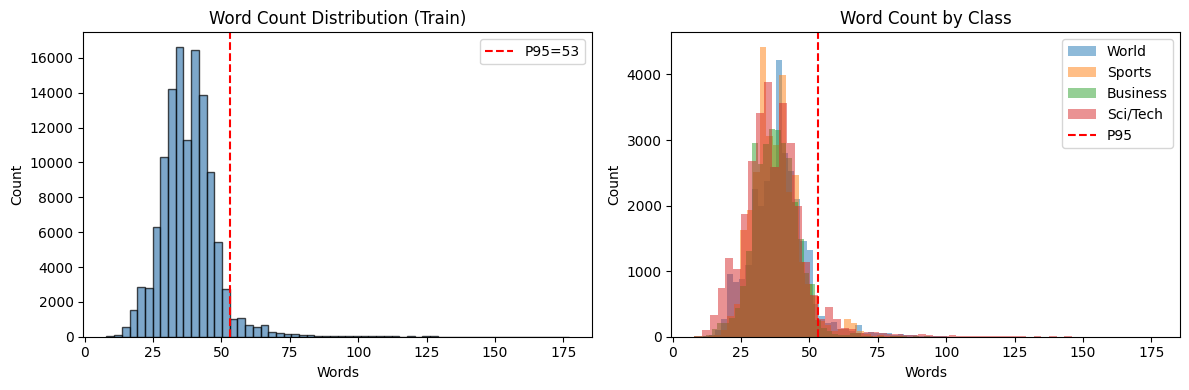


  Estimated BPE lengths (1.4x expansion factor):
    P95 ≈ 74 BPE tokens
    P99 ≈ 98 BPE tokens
    Planned MAX_LENGTH = 128 → covers well beyond P99


In [3]:
# Step 3: Length Distribution
"""
Determine text lengths to inform MAX_LENGTH for the classification
tokenizer. Unlike translation, classification texts can vary widely
(short headlines to full paragraphs).
"""

print("=" * 60)
print("[3/5] LENGTH DISTRIBUTION")
print("=" * 60)

# Character and word lengths
char_lengths = train_df['text'].str.len()
word_lengths = train_df['text'].str.split().str.len()

print(f"\n  {'':=<60}")
print(f"  Text Length Statistics (train set)")
print(f"  {'':=<60}")
print(f"  {'Metric':<12} {'Characters':>12} {'Words':>10}")
print(f"  {'-'*34}")
print(f"  {'Mean':<12} {char_lengths.mean():>12.0f} {word_lengths.mean():>10.1f}")
print(f"  {'Median':<12} {char_lengths.median():>12.0f} {word_lengths.median():>10.1f}")
print(f"  {'P90':<12} {char_lengths.quantile(0.90):>12.0f} {word_lengths.quantile(0.90):>10.0f}")
print(f"  {'P95':<12} {char_lengths.quantile(0.95):>12.0f} {word_lengths.quantile(0.95):>10.0f}")
print(f"  {'P99':<12} {char_lengths.quantile(0.99):>12.0f} {word_lengths.quantile(0.99):>10.0f}")
print(f"  {'Max':<12} {char_lengths.max():>12} {word_lengths.max():>10}")
print(f"  {'Min':<12} {char_lengths.min():>12} {word_lengths.min():>10}")

# Per-class length stats
print(f"\n  {'':=<60}")
print(f"  Mean Word Length by Class")
print(f"  {'':=<60}")
for label in sorted(CLASS_NAMES.keys()):
    class_lens = train_df[train_df['label'] == label]['text'].str.split().str.len()
    print(f"  {CLASS_NAMES[label]:<12} mean={class_lens.mean():.1f}, median={class_lens.median():.0f}, P95={class_lens.quantile(0.95):.0f}")

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(word_lengths, bins=60, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(word_lengths.quantile(0.95), color='red', linestyle='--', label=f'P95={word_lengths.quantile(0.95):.0f}')
axes[0].set_title('Word Count Distribution (Train)')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Count')
axes[0].legend()

for label in sorted(CLASS_NAMES.keys()):
    class_lens = train_df[train_df['label'] == label]['text'].str.split().str.len()
    axes[1].hist(class_lens, bins=60, alpha=0.5, label=CLASS_NAMES[label])
axes[1].axvline(word_lengths.quantile(0.95), color='red', linestyle='--', label='P95')
axes[1].set_title('Word Count by Class')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# BPE length estimate
# BPE expands ~1.3-1.5x on English text (from translation EDA)
est_bpe_p95 = word_lengths.quantile(0.95) * 1.4
est_bpe_p99 = word_lengths.quantile(0.99) * 1.4
print(f"\n  Estimated BPE lengths (1.4x expansion factor):")
print(f"    P95 ≈ {est_bpe_p95:.0f} BPE tokens")
print(f"    P99 ≈ {est_bpe_p99:.0f} BPE tokens")
print(f"    Planned MAX_LENGTH = 128 → covers well beyond P99")

In [4]:
# Step 4: Vocabulary + Word Frequency
"""
Analyze the word-level vocabulary to understand the feature space
before BPE tokenization. Look for class-discriminative words that
the model should learn to associate with specific categories.
"""

from collections import Counter

print("=" * 60)
print("[4/5] VOCABULARY + WORD FREQUENCY")
print("=" * 60)

# Overall vocab stats
all_words = []
for text in texts:
    all_words.extend(text.lower().split())

word_counts = Counter(all_words)
total_words = len(all_words)
unique_words = len(word_counts)

print(f"\n  Total words:  {total_words:,}")
print(f"  Unique words: {unique_words:,}")
print(f"  Avg frequency: {total_words / unique_words:.1f}")

# Top 20 overall
print(f"\n  {'':=<60}")
print(f"  Top 20 Words (all classes)")
print(f"  {'':=<60}")
for word, count in word_counts.most_common(20):
    pct = count / total_words * 100
    print(f"    {word:<15} {count:>8,} ({pct:.2f}%)")

# Top 10 per class (excluding stopwords)
stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'in', 'on',
             'at', 'to', 'for', 'of', 'and', 'or', 'but', 'it', 'its',
             'that', 'this', 'with', 'from', 'by', 'as', 'be', 'has',
             'had', 'have', 'not', 'he', 'she', 'they', 'we', 'will',
             'said', '-', 'quot;', '#39;', '\\'}

print(f"\n  {'':=<60}")
print(f"  Top 10 Per Class (excluding stopwords)")
print(f"  {'':=<60}")

for label in sorted(CLASS_NAMES.keys()):
    class_texts = train_df[train_df['label'] == label]['text'].tolist()
    class_words = []
    for t in class_texts:
        class_words.extend(t.lower().split())
    class_counts = Counter(class_words)

    # Filter stopwords
    filtered = [(w, c) for w, c in class_counts.most_common(100) if w not in stopwords][:10]
    print(f"\n  {CLASS_NAMES[label]}:")
    for word, count in filtered:
        print(f"    {word:<15} {count:>6,}")

# Vocab coverage at different sizes
print(f"\n  {'':=<60}")
print(f"  Vocab Coverage (cumulative)")
print(f"  {'':=<60}")
sorted_counts = sorted(word_counts.values(), reverse=True)
cumsum = np.cumsum(sorted_counts)

for size in [1000, 5000, 10000, 16000, 30000]:
    if size <= len(sorted_counts):
        coverage = cumsum[size - 1] / total_words * 100
        print(f"    Top {size:>6,} words → {coverage:.1f}% of all text")
    else:
        print(f"    Top {size:>6,} words → 100.0% (only {unique_words:,} unique)")

[4/5] VOCABULARY + WORD FREQUENCY

  Total words:  4,541,694
  Unique words: 158,733
  Avg frequency: 28.6

  Top 20 Words (all classes)
    the              203,234 (4.47%)
    to               118,923 (2.62%)
    a                107,286 (2.36%)
    of                97,862 (2.15%)
    in                95,251 (2.10%)
    and               68,627 (1.51%)
    on                56,311 (1.24%)
    for               50,070 (1.10%)
    -                 39,105 (0.86%)
    #39;s             31,129 (0.69%)
    that              27,533 (0.61%)
    with              26,611 (0.59%)
    as                25,125 (0.55%)
    at                24,867 (0.55%)
    its               21,921 (0.48%)
    is                21,800 (0.48%)
    new               21,047 (0.46%)
    by                20,697 (0.46%)
    has               18,908 (0.42%)
    it                18,595 (0.41%)

  Top 10 Per Class (excluding stopwords)

  World:
    #39;s            6,584
    his              4,844
    iraq         

In [5]:
# Step 5: Summary → Preprocessing Decisions
"""
Consolidate findings into concrete decisions for the classification
preprocessing script.
"""

print("=" * 60)
print("[5/5] SUMMARY → PREPROCESSING DECISIONS")
print("=" * 60)

print(f"""
  ============================================================
  AG News Preprocessing Decisions
  ============================================================
  {'Setting':<28} {'Value':>25}
  {'-'*53}
  {'Dataset':<28} {'AG News (4-class)':>25}
  {'Train / Val / Test':<28} {'108K / 12K / 7.6K':>25}
  {'Tokenization':<28} {'BPE (SentencePiece)':>25}
  {'BPE vocab size':<28} {'16,000 (English only)':>25}
  {'MAX_LENGTH':<28} {'128 tokens':>25}
  {'Special tokens':<28} {'PAD=0, BOS=1, EOS=2, UNK=3':>25}
  {'Labels':<28} {'0-3 (already 0-indexed)':>25}
  {'Random state':<28} {'113':>25}

  Cleaning steps (in order):
    1. html.unescape()         → fix &lt; &gt; &amp; entities
    2. Strip HTML tags         → remove <strong> etc. left by unescape
    3. Replace ' quot;' → '"'  → fix malformed quote artifacts (26.7%)
    4. Replace '#39;' → "'"    → fix malformed apostrophe artifacts
    5. Replace '\\' → ' '      → fix escaped newlines (11.0%)
    6. Collapse whitespace     → normalize multiple spaces to single
    7. Strip + lowercase       → consistent casing

  Split strategy:
    - Test set: use original 7,600 samples (pre-split by dataset)
    - Train 120K → split 90/10 → 108K train + 12K val
    - Stratified split to maintain class balance
    - RANDOM_STATE = 113

  Notes:
    - No URLs to strip (only 1.5%, low impact)
    - No emails found
    - All classes have similar length distributions (mean 37-39 words)
    - Perfectly balanced: 25% per class in both train and test
    - DistilBERT fine-tuning will use its own WordPiece tokenizer,
      NOT this BPE model. The BPE preprocessing is for the
      from-scratch encoder-only Transformer only.
""")

[5/5] SUMMARY → PREPROCESSING DECISIONS

  AG News Preprocessing Decisions
  Setting                                          Value
  -----------------------------------------------------
  Dataset                              AG News (4-class)
  Train / Val / Test                   108K / 12K / 7.6K
  Tokenization                       BPE (SentencePiece)
  BPE vocab size                   16,000 (English only)
  MAX_LENGTH                                  128 tokens
  Special tokens               PAD=0, BOS=1, EOS=2, UNK=3
  Labels                         0-3 (already 0-indexed)
  Random state                                       113

  Cleaning steps (in order):
    1. html.unescape()         → fix &lt; &gt; &amp; entities
    2. Strip HTML tags         → remove <strong> etc. left by unescape
    3. Replace ' quot;' → '"'  → fix malformed quote artifacts (26.7%)
    4. Replace '#39;' → "'"    → fix malformed apostrophe artifacts
    5. Replace '\' → ' '      → fix escaped newlines 